In [68]:
import os
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
import torchvision.transforms as transforms
import torch


In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 10

In [70]:

class MultiTaskDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for root, dirs, files in os.walk(root_dir):
            for file in files:
                #  đọc cả .xls và .xlsx
                if file.lower().endswith((".xls", ".xlsx")):
                    excel_path = os.path.join(root, file)
                    print("Found Excel:", excel_path)

                    df = pd.read_excel(excel_path)

                    # fix khoảng trắng tên cột
                    df.columns = df.columns.str.strip()
                    print("Columns:", df.columns)

                    for _, row in df.iterrows():
                        try:
                            img_name = str(row['Image name']).strip()

                            # thử 2 kiểu path
                            path1 = os.path.join(root, img_name)
                            path2 = os.path.join(root, img_name + ".tif")

                            if os.path.exists(path1):
                                img_path = path1
                            elif os.path.exists(path2):
                                img_path = path2
                            else:
                                continue

                            label_dr = int(row['Retinopathy grade'])
                            label_dme = int(row['Risk of macular edema'])

                            self.samples.append((img_path, label_dr, label_dme))

                        except Exception as e:
                            print("Error:", e)

        print("\n Total samples:", len(self.samples))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, dr, dme = self.samples[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(dr), torch.tensor(dme)

In [71]:
root = "/kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4"

for folder in os.listdir(root):
    print(folder)

Base14
Base12
Base33
Base22
Base34
Base23
Base11
Base31
Base13
Base32
Base21
Base24


In [72]:
full_dataset = MultiTaskDataset(
    root_dir="/kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4",
    transform=None
)

print("Total samples:", len(dataset))

Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base14/Annotation Base14.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base12/Annotation Base12.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base33/Annotation Base33.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base22/Annotation Base22.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/d

In [73]:
import torch

dataset_size = len(full_dataset)
indices = torch.randperm(dataset_size)

train_size = int(0.8 * dataset_size)

train_indices = indices[:train_size]
val_indices   = indices[train_size:]

In [74]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.2, 0.2, 0.2),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [75]:
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [76]:
from torch.utils.data import Subset

train_dataset = Subset(
    MultiTaskDataset(
        root_dir="/kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4",
        transform=train_transform
    ),
    train_indices
)

val_dataset = Subset(
    MultiTaskDataset(
        root_dir="/kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4",
        transform=val_transform
    ),
    val_indices
)

Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base14/Annotation Base14.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base12/Annotation Base12.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base33/Annotation Base33.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/dataset_zip_pbl4/Base22/Annotation Base22.xls
Columns: Index(['Image name', 'Ophthalmologic department', 'Retinopathy grade',
       'Risk of macular edema'],
      dtype='object')
Found Excel: /kaggle/input/datasets/longvu1611/dataset/d

In [77]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [78]:
images, dr, dme = next(iter(train_loader))

print(images.shape)
print("DR:", dr[:5])
print("DME:", dme[:5])

torch.Size([16, 3, 224, 224])
DR: tensor([1, 2, 0, 0, 3])
DME: tensor([0, 0, 0, 0, 2])


In [79]:
import torchvision.models as models
import torch.nn as nn

# load file
state = torch.load("/kaggle/input/models/longvu1611/model/pytorch/default/1/classifier.pt", map_location=device)

# lấy đúng weight
if 'model_state_dict' in state:
    state_dict = state['model_state_dict']
elif 'state_dict' in state:
    state_dict = state['state_dict']
else:
    state_dict = state  # fallback

# tạo model
backbone = models.resnet50(pretrained=False)
backbone.fc = nn.Linear(backbone.fc.in_features, 5)

# load
backbone.load_state_dict(state_dict, strict=False)

print(" Loaded OK")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


 Loaded OK


In [80]:
class MultiTaskModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        
        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.flatten = nn.Flatten()
        
        in_features = backbone.fc.in_features
        
        self.head_dr = nn.Linear(in_features, 5)
        self.head_dme = nn.Linear(in_features, 3)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        
        out_dr = self.head_dr(x)
        out_dme = self.head_dme(x)
        
        return out_dr, out_dme

In [81]:
model = MultiTaskModel(backbone).to(device)

In [82]:
criterion_dr = nn.CrossEntropyLoss()
criterion_dme = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

In [83]:
train_losses = []
val_losses = []

train_acc_dr_list = []
train_acc_dme_list = []

val_acc_dr_list = []
val_acc_dme_list = []

In [84]:
best_val_acc = 0

for epoch in range(EPOCHS):

    # ================= TRAIN =================
    model.train()

    total_loss = 0
    total_loss_dr = 0
    total_loss_dme = 0

    correct_dr = 0
    correct_dme = 0
    total = 0

    for images, label_dr, label_dme in train_loader:
        images = images.to(device)
        label_dr = label_dr.to(device)
        label_dme = label_dme.to(device)

        optimizer.zero_grad()

        out_dr, out_dme = model(images)

        loss_dr = criterion_dr(out_dr, label_dr)
        loss_dme = criterion_dme(out_dme, label_dme)
        loss = loss_dr + loss_dme

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_loss_dr += loss_dr.item()
        total_loss_dme += loss_dme.item()

        _, pred_dr = torch.max(out_dr, 1)
        _, pred_dme = torch.max(out_dme, 1)

        correct_dr += (pred_dr == label_dr).sum().item()
        correct_dme += (pred_dme == label_dme).sum().item()

        total += label_dr.size(0)

    train_loss = total_loss / len(train_loader)
    train_loss_dr = total_loss_dr / len(train_loader)
    train_loss_dme = total_loss_dme / len(train_loader)

    train_acc_dr = correct_dr / total
    train_acc_dme = correct_dme / total

    # ================= VALIDATION =================
    model.eval()

    total_loss = 0
    total_loss_dr = 0
    total_loss_dme = 0

    correct_dr = 0
    correct_dme = 0
    total = 0

    with torch.no_grad():
        for images, label_dr, label_dme in val_loader:

            images = images.to(device)
            label_dr = label_dr.to(device)
            label_dme = label_dme.to(device)

            out_dr, out_dme = model(images)

            loss_dr = criterion_dr(out_dr, label_dr)
            loss_dme = criterion_dme(out_dme, label_dme)
            loss = loss_dr + loss_dme

            total_loss += loss.item()
            total_loss_dr += loss_dr.item()
            total_loss_dme += loss_dme.item()

            pred_dr = torch.argmax(out_dr, dim=1)
            pred_dme = torch.argmax(out_dme, dim=1)

            correct_dr += (pred_dr == label_dr).sum().item()
            correct_dme += (pred_dme == label_dme).sum().item()

            total += label_dr.size(0)

    val_loss = total_loss / len(val_loader)
    val_loss_dr = total_loss_dr / len(val_loader)
    val_loss_dme = total_loss_dme / len(val_loader)

    val_acc_dr = correct_dr / total
    val_acc_dme = correct_dme / total

    # ================= SAVE MODEL =================
    avg_val_acc = (val_acc_dr + val_acc_dme) / 2

    if avg_val_acc > best_val_acc:
        best_val_acc = avg_val_acc
        torch.save(model.state_dict(), "best_model.pth")
        print(">> Saved best model!")

    # ================= SAVE HISTORY =================
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_acc_dr_list.append(train_acc_dr)
    train_acc_dme_list.append(train_acc_dme)

    val_acc_dr_list.append(val_acc_dr)
    val_acc_dme_list.append(val_acc_dme)

    # ================= PRINT =================
    print(
        f"Epoch [{epoch+1}/{EPOCHS}]\n"
        f"Train | Loss: {train_loss:.4f} | DR: {train_loss_dr:.4f}, Acc: {train_acc_dr:.4f} | "
        f"DME: {train_loss_dme:.4f}, Acc: {train_acc_dme:.4f}\n"
        f"Val   | Loss: {val_loss:.4f} | DR: {val_loss_dr:.4f}, Acc: {val_acc_dr:.4f} | "
        f"DME: {val_loss_dme:.4f}, Acc: {val_acc_dme:.4f}\n"
    )

>> Saved best model!
Epoch [1/10]
Train | Loss: 1.7859 | DR: 1.1974, Acc: 0.4938 | DME: 0.5885, Acc: 0.7833
Val   | Loss: 1.5380 | DR: 1.1603, Acc: 0.5750 | DME: 0.3777, Acc: 0.8792

>> Saved best model!
Epoch [2/10]
Train | Loss: 1.3875 | DR: 0.9694, Acc: 0.5948 | DME: 0.4181, Acc: 0.8490
Val   | Loss: 1.3243 | DR: 0.9553, Acc: 0.6583 | DME: 0.3690, Acc: 0.8958

Epoch [3/10]
Train | Loss: 1.3436 | DR: 0.9511, Acc: 0.5927 | DME: 0.3925, Acc: 0.8646
Val   | Loss: 1.3836 | DR: 1.1187, Acc: 0.5958 | DME: 0.2649, Acc: 0.9167

Epoch [4/10]
Train | Loss: 1.2189 | DR: 0.8692, Acc: 0.6542 | DME: 0.3496, Acc: 0.8760
Val   | Loss: 1.4293 | DR: 1.1261, Acc: 0.5958 | DME: 0.3032, Acc: 0.9125

Epoch [5/10]
Train | Loss: 1.1941 | DR: 0.8409, Acc: 0.6802 | DME: 0.3532, Acc: 0.8698
Val   | Loss: 1.2513 | DR: 0.9422, Acc: 0.6333 | DME: 0.3091, Acc: 0.8875

Epoch [6/10]
Train | Loss: 1.1273 | DR: 0.8182, Acc: 0.6562 | DME: 0.3090, Acc: 0.8823
Val   | Loss: 1.2815 | DR: 0.9455, Acc: 0.6500 | DME: 0.3360,

In [85]:
model.eval()

with torch.no_grad():
    images, label_dr, label_dme = next(iter(val_loader))

    images = images.to(device)
    label_dr = label_dr.to(device)
    label_dme = label_dme.to(device)

    out_dr, out_dme = model(images)

    pred_dr = torch.argmax(out_dr, dim=1)
    pred_dme = torch.argmax(out_dme, dim=1)

print("=== DR ===")
print("Pred:", pred_dr[:5].cpu())
print("True:", label_dr[:5].cpu())

print("\n=== DME ===")
print("Pred:", pred_dme[:5].cpu())
print("True:", label_dme[:5].cpu())

=== DR ===
Pred: tensor([0, 0, 0, 0, 0])
True: tensor([0, 0, 0, 2, 0])

=== DME ===
Pred: tensor([0, 0, 0, 0, 0])
True: tensor([0, 0, 0, 0, 0])


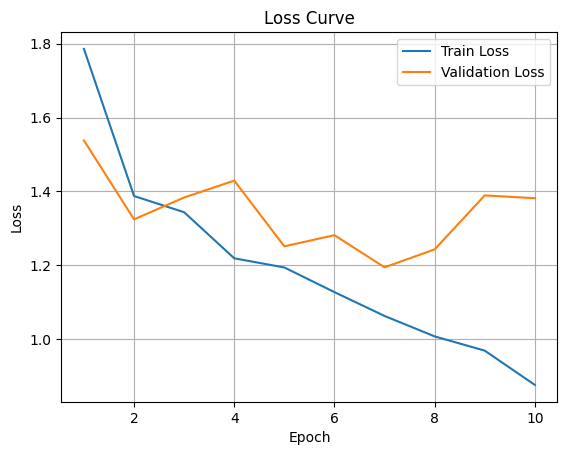

In [86]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid()
plt.show()

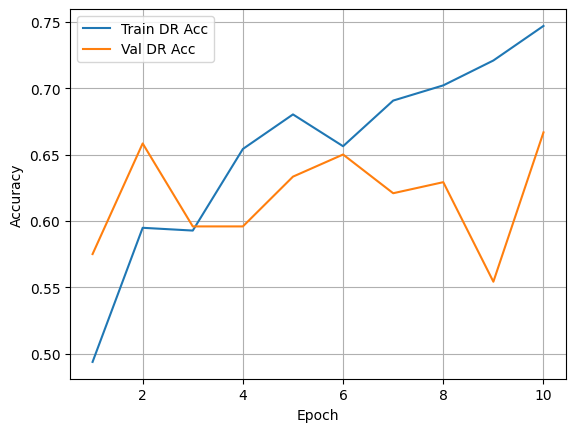

In [89]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_acc_dr_list) + 1)

plt.figure()
plt.plot(epochs, train_acc_dr_list, label="Train DR Acc")
plt.plot(epochs, val_acc_dr_list, label="Val DR Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

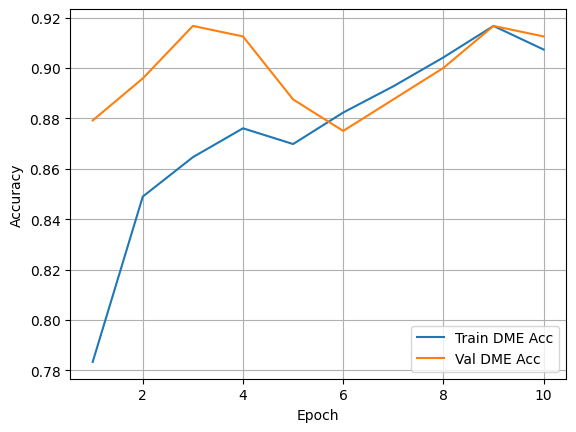

In [90]:


epochs = range(1, len(train_acc_dme_list) + 1)

plt.figure()
plt.plot(epochs, train_acc_dme_list, label="Train DME Acc")
plt.plot(epochs, val_acc_dme_list, label="Val DME Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

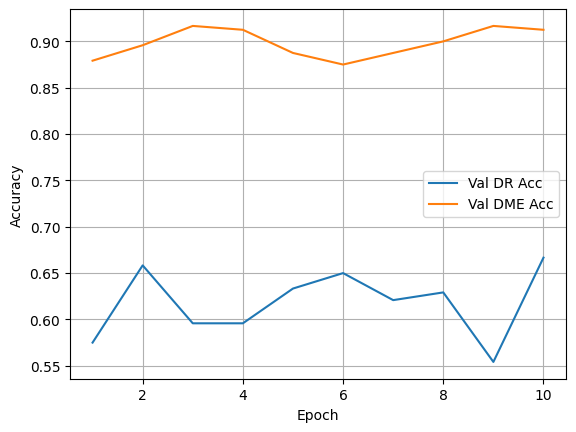

In [92]:


epochs = range(1, len(val_acc_dr_list) + 1)

plt.figure()

plt.plot(epochs, val_acc_dr_list, label="Val DR Acc")
plt.plot(epochs, val_acc_dme_list, label="Val DME Acc")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()